# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import warnings
warnings.filterwarnings('ignore') # To prevent warnings such args/ parameter deprecated warnings

pd.set_option('display.max_columns',1000) # Default is 20 so increasing to not have problem further in project due to hidden columns
import missingno as mng # To visualize the missingness of the columns

<IPython.core.display.Javascript object>

### Dataset Loading

In [2]:
# Load Dataset

sales_df = pd.read_csv('sales data-set.csv')
stores_df = pd.read_csv('stores data-set.csv')
features_df = pd.read_csv('Features data set.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format="%d/%m/%Y")
features_df['Date'] = pd.to_datetime(features_df['Date'], format="%d/%m/%Y")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
merged_df = pd.merge(sales_df, stores_df, on='Store', how='left')

<IPython.core.display.Javascript object>

In [5]:
data = pd.merge(merged_df, features_df, on=['Store', 'Date', 'IsHoliday'], how='left')

<IPython.core.display.Javascript object>

### Dataset First View

In [6]:
# Dataset First Look

data.sample(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
31103,4,12,2010-04-30,8605.58,False,A,205863,53.04,2.787,NaN,NaN,NaN,NaN,NaN,126.380567,7.896
343555,36,46,2010-06-11,3112.17,False,A,39910,82.30,2.615,NaN,NaN,NaN,NaN,NaN,210.213567,8.464
190079,20,21,2012-02-03,13108.45,False,A,203742,39.93,3.617,58928.52,8766.77,226.27,53603.99,8301.25,213.023622,6.961
235902,24,90,2012-08-03,75179.83,False,A,203819,73.26,3.819,11887.54,557.10,138.39,9345.76,2781.67,138.173581,8.953
342812,36,25,2011-01-07,5.75,False,A,39910,54.11,2.942,NaN,NaN,NaN,NaN,NaN,210.184236,8.395


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count

print('The dataset has {} rows and {} columns'.format(data.shape[0],data.shape[1]))

The dataset has 421570 rows and 16 columns


### Dataset Information

In [8]:
# Dataset Info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count

data.duplicated().sum()

0

#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count

missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
missing_df

<IPython.core.display.Javascript object>

,Missing Values,Percentage
MarkDown2,310322,73.611025
MarkDown4,286603,67.984676
MarkDown3,284479,67.480845
MarkDown1,270889,64.257181
MarkDown5,270138,64.079038


<IPython.core.display.Javascript object>

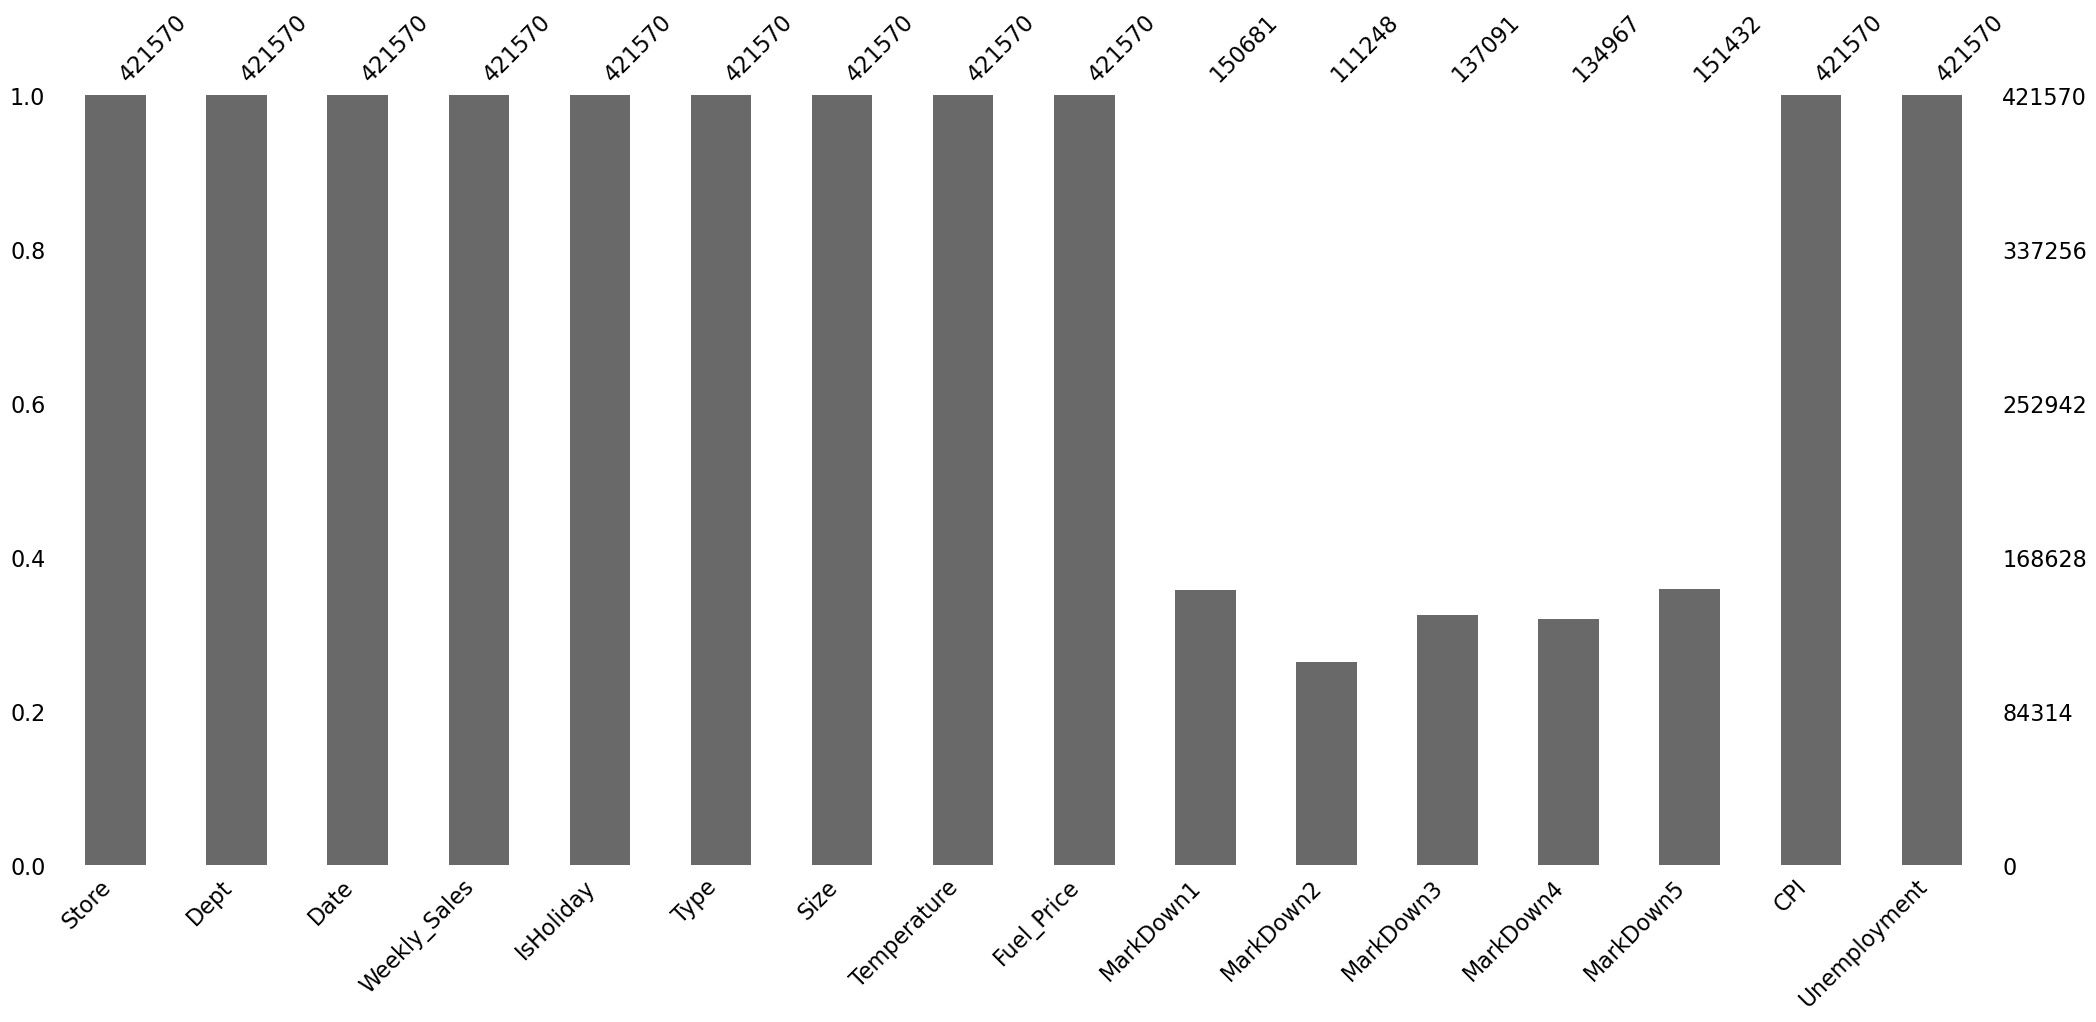

In [11]:
# Visualizing the missing values

mng.bar(data)
plt.show()

### What did you know about your dataset?

The dataset contains 421,570 rows and 16 columns, representing retail sales data across multiple stores and departments with no duplicates. It includes variables like Store, Dept, Date, Weekly_Sales, IsHoliday, Type, Size, Temperature, Fuel_Price, MarkDown1–5, CPI, and Unemployment. Most columns are complete except for MarkDown1–5, which have 64–73% missing values, likely due to inconsistent promotion tracking. The dataset enables analysis of sales trends influenced by store characteristics, promotions, holidays, and regional economic and environmental factors, with data types including integers, floats, boolean, datetime, and categorical.

## ***2. Understanding Your Variables***

In [12]:
# Dataset Columns

data.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment'],
      dtype='object')

In [13]:
# Dataset Describe

data.describe()

,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,136727.915739,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296


In [14]:
data.sample()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
263321,27,54,2011-10-07,114.92,False,A,204184,56.91,3.775,NaN,NaN,NaN,NaN,NaN,140.43475,7.906


### Variables Description

Store: The unique identifier for the retail store

Dept: The department number within the store 

Date: The date of the observation

Weekly_Sales: The total sales for the department in the given store for the specified week 

IsHoliday: A boolean indicating whether the week includes a holiday (e.g., False means no holiday)

Type: The type or category of the store (e.g., B, which could represent a specific store format or size category)

Size: The size of the store, likely in square feet (e.g., 93638 square feet)

Temperature: The average temperature in the region of the store for the week, in degrees Fahrenheit 

Fuel_Price: The average fuel price in the region of the store for the week, in dollars per gallon 

MarkDown1, MarkDown2, MarkDown3, MarkDown4, MarkDown5: Promotional markdown amounts (discounts or price reductions) applied during the week, likely in dollars. NaN indicates no markdown data is available for that period

CPI: The Consumer Price Index for the region during the week, a measure of inflation or cost of living 

Unemployment: The unemployment rate in the region for the week, expressed as a percentage (e.g., 10.524%)

### Check Unique Values for each variable.

In [15]:
# Check Unique Values for each variable.

unique_values = data.nunique().sort_values(ascending=False)
unique_values_df = pd.DataFrame({'Column': unique_values.index, 'Unique Values': unique_values.values})

unique_values_df

<IPython.core.display.Javascript object>

,Column,Unique Values
0,Weekly_Sales,359464
1,Temperature,3528
2,MarkDown5,2293
3,MarkDown1,2277
4,CPI,2145
5,MarkDown4,1944
6,MarkDown3,1662
7,MarkDown2,1499
8,Fuel_Price,892
9,Unemployment,349


### Observations :

This retail dataset with 421,570 rows shows a ton of variety: Weekly_Sales has 359,464 unique values, hinting at diverse sales across stores and departments. Temperature varies widely with 3,528 unique values, reflecting different regional conditions. MarkDown1–5, despite 64–73% missing data, still show 1,499–2,293 unique promotional amounts. CPI (2,145), Unemployment (349), and Fuel_Price (892) suggest regional economic shifts. With 143 weeks, 45 stores, 81 departments, and 3 store types, it’s great for digging into sales trends, especially with complete data for most columns except markdowns.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
# Write your code to make your dataset analysis ready.

### What all manipulations have you done and insights you found?

The project used three datasets: sales data, stores data and Features data
The Date column was converted to datetime format in both sales and features datasets.
All three datasets were merged using common keys: Store,Date and IsHoliday
The final merged dataset was stored in a variable named ata
This dataset is now ready for further analysis, including missing value treatment, feature engineering, and model training

No advanced transformations (like missing value imputation, encoding, or scaling) are performed at this stage
These steps are handled in their dedicated sections as per the guidelines


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

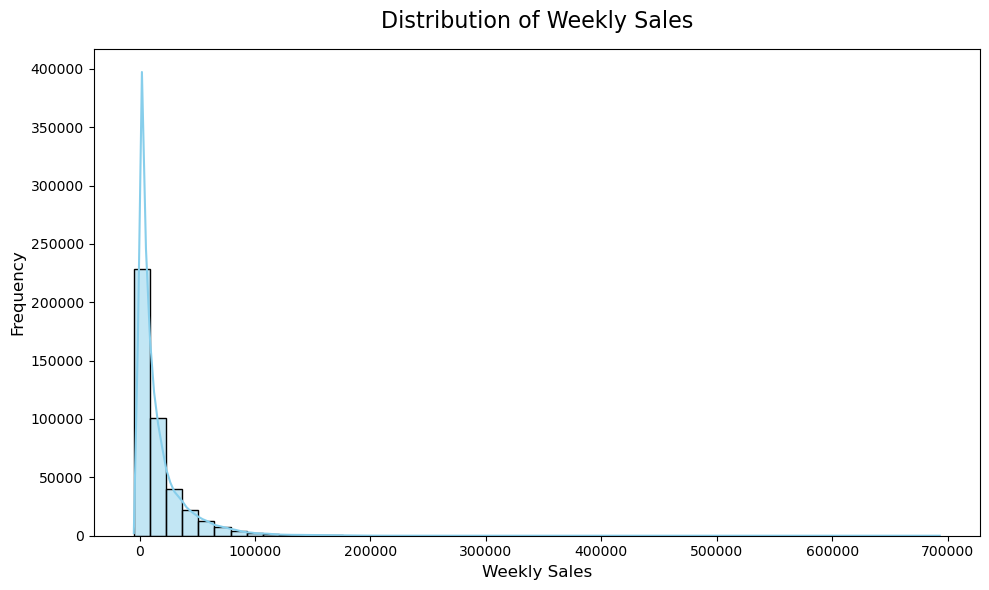

In [17]:
# Chart - 1 visualization code

plt.figure(figsize=(10, 6))
sns.histplot(data['Weekly_Sales'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Weekly Sales', fontsize=16, pad=15)
plt.xlabel('Weekly Sales', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose this histogram with a KDE overlay because it effectively visualizes the distribution of weekly sales data. This type of chart allows for a clear understanding of how sales values are spread across different ranges whether they are skewed, have outliers, or cluster around certain values. It is a fundamental step in sales data analysis to identify patterns and potential anomalies.

##### 2. What is/are the insight(s) found from the chart?

The weekly sales data is heavily right-skewed, meaning most sales values are concentrated near the lower end with a long tail extending to very high sales amounts
There are frequent lowervalue sales indicating many small transactions or weeks with low sales volume and relatively few very high sales weeks.
The distribution shape suggests potential outliers or high sales spikes that may warrant further investigation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the sales distribution helps in forecasting, inventory management and targeted marketing strategies. Identifying that sales are skewed towards lower values enables the business to tailor promotions to increase mid-range sales or investigate ways to convert more frequent smaller sales into larger ones.

Negativ : The presence of a heavy skew and potential outliers could indicate inconsistent sales performance, which may challenge stability or growth if not managed.

#### Chart - 2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

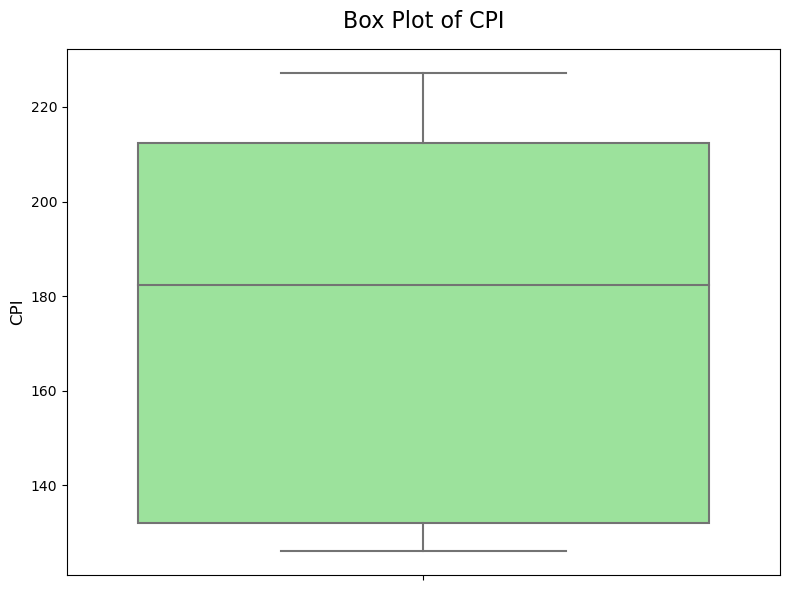

In [18]:
# Chart - 2 visualization code

plt.figure(figsize=(8, 6))
sns.boxplot(y=data['CPI'], color='lightgreen')
plt.title('Box Plot of CPI', fontsize=16, pad=15)
plt.ylabel('CPI', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Box plots highlight median, quartiles, and outliers for numerical variables.

##### 2. What is/are the insight(s) found from the chart?

No clear outliers are visible, suggesting a relatively consistent dataset without extreme anomalies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding CPIs distribution helps businesses anticipate inflation trends, adjust pricing strategies and manage costs effectively. The absence of extreme outliers indicates reliable data

Negative : The wide spread in CPI values could signal volatility in the price environment which may increase uncertainty for budgeting and pricing decisions 

#### Chart - 3

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

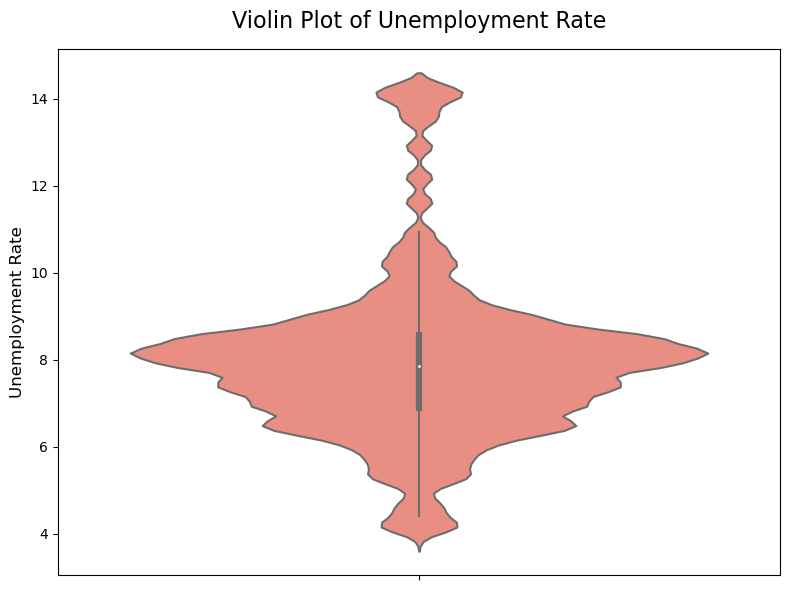

In [19]:
# Chart - 3 visualization code

plt.figure(figsize=(8, 6))
sns.violinplot(y=data['Unemployment'], color='salmon')
plt.title('Violin Plot of Unemployment Rate', fontsize=16, pad=15)
plt.ylabel('Unemployment Rate', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Violin plots combine box plots and KDE, showing both summary statistics and distribution shape.

##### 2. What is/are the insight(s) found from the chart?

Unemployment shows a wider distribution, with some regions having higher rates, affecting purchasing power.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the distribution of unemployment rates helps policymakers and businesses anticipate labor market conditions, inform hiring decisions

Negativr : The presence of outliers with higher unemployment rates might signal periods of economic distress

#### Chart - 4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

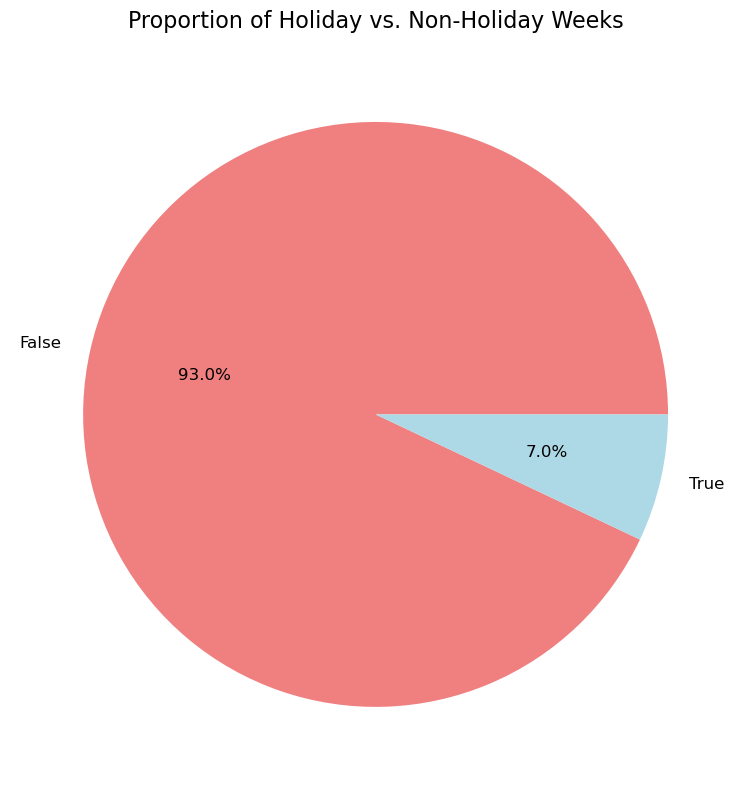

In [20]:
# Chart - 4 visualization code

plt.figure(figsize=(8, 8))
data['IsHoliday'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'lightblue'], textprops={'fontsize': 12})
plt.title('Proportion of Holiday vs. Non-Holiday Weeks', fontsize=16, pad=15)
plt.ylabel('')
plt.tight_layout()

##### 1. Why did you pick the specific chart?

Pie charts effectively display binary categorical proportions.

##### 2. What is/are the insight(s) found from the chart?

The vast majority of weeks (93%) are non-holiday weeks, with only 7% classified as holiday weeks.
This indicates that holiday periods are relatively rare compared to regular weeks

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Knowing that holiday weeks are only a small fraction of total weeks helps businesses plan for consistent operational periods and allocate resources efficiently.

#### Chart - 5

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

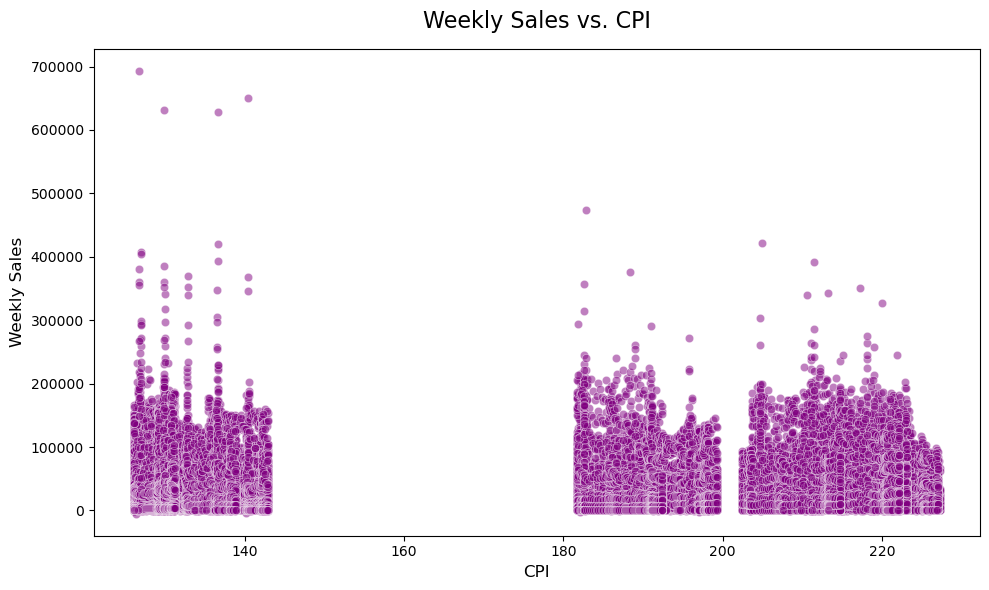

In [21]:
# Chart - 5 visualization code

plt.figure(figsize=(10, 6))
sns.scatterplot(x='CPI', y='Weekly_Sales', data=data, alpha=0.5, color='purple')
plt.title('Weekly Sales vs. CPI', fontsize=16, pad=15)
plt.xlabel('CPI', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

Scatter plots reveal correlations and patterns between two numerical variables.


##### 2. What is/are the insight(s) found from the chart?

There isn’t a clear linear correlation between CPI and Weekly Sales. A few high-sales outliers exist across various CPI values, showing some individual weeks experienced unusually high sales regardless of the CPI.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding that sales behavior varies across CPI clusters can support targeted marketing and pricing strategies 

#### Chart - 6

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

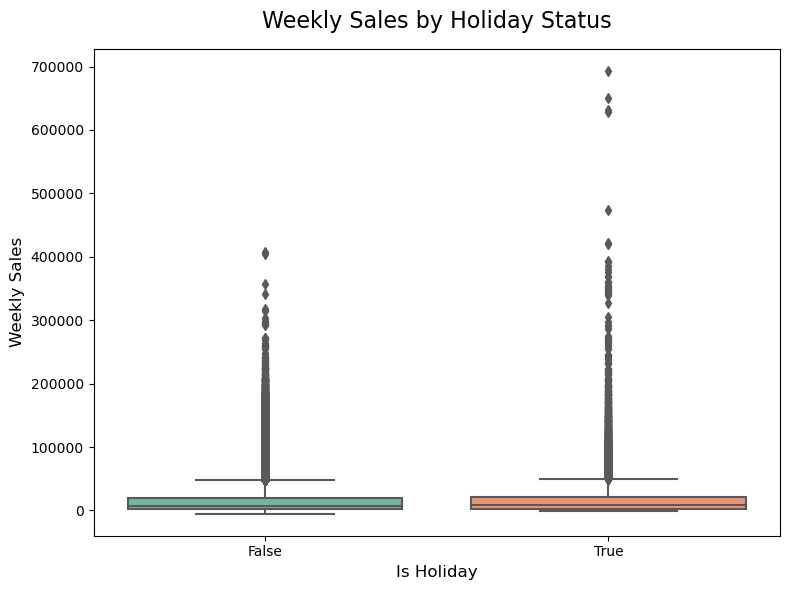

In [22]:
# Chart - 6 visualization code

plt.figure(figsize=(8, 6))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=data, palette='Set2')
plt.title('Weekly Sales by Holiday Status', fontsize=16, pad=15)
plt.xlabel('Is Holiday', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

Box plots show differences in medians and spread across categories.

##### 2. What is/are the insight(s) found from the chart?

Weekly sales during holiday weeks tend to have a slightly higher median Both holiday and non-holiday weeks show numerous high-value outliers

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Recognizing that holidays slightly increase sales can help businesses optimize inventory,


#### Chart - 7

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

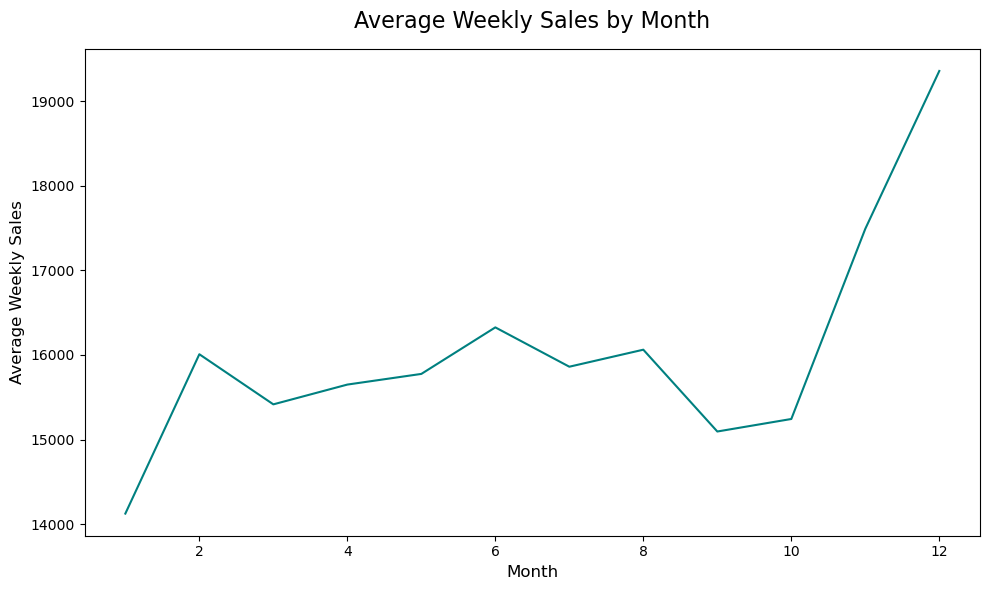

In [23]:
# Chart - 7 visualization code

from datetime import datetime as dt
data['Month']  = data['Date'].dt.month

plt.figure(figsize=(10, 6))
sns.lineplot(x='Month', y='Weekly_Sales', data=data, estimator='mean', ci=None, color='teal')
plt.title('Average Weekly Sales by Month', fontsize=16, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Weekly Sales', fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

Line plots are excellent for time-based trends.

##### 2. What is/are the insight(s) found from the chart?

weekly sales show a gradual increase from January to mid-year. There is a noticeable peak in December where sales sharply rise, likely due to holiday shopping and year-end demand. The lowest average sales appear early in the year, suggesting seasonal seasonality impacting sales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Recognizing the December sales peak enables businesses to prepare for high demand through inventory buildup, marketing campaigns, and staffing adjustments

Nagative : The relatively lower sales in early months may highlight periods of weak demand. Without strategic intervention, this seasonality could result in underperformance

#### Chart - 8

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

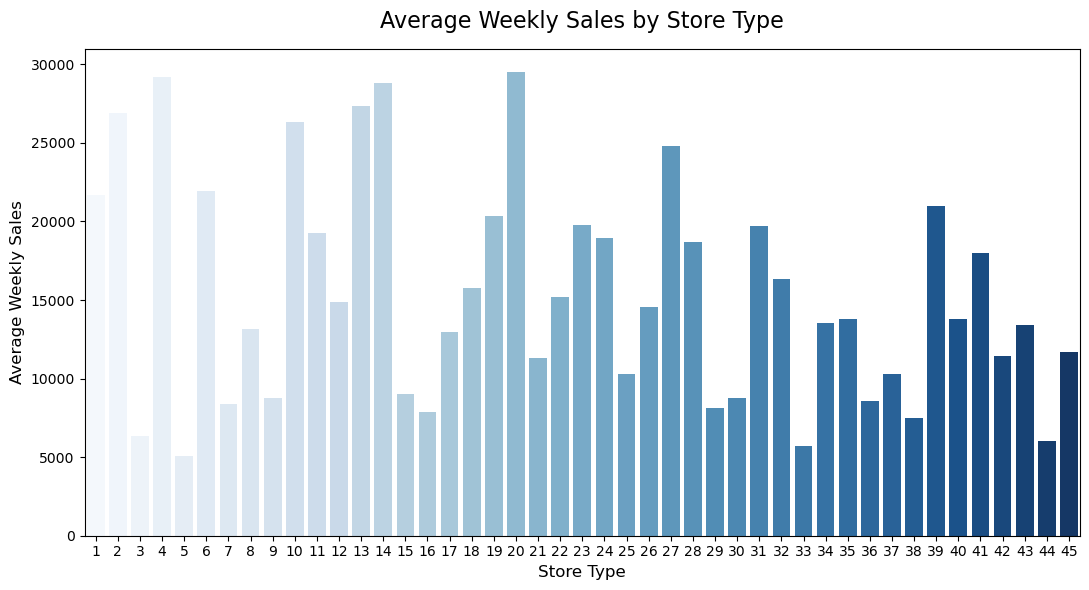

In [24]:
# Chart - 8 visualization code

plt.figure(figsize=(11, 6))
sns.barplot(x='Store', y='Weekly_Sales', data=data, estimator=np.mean, ci=None, palette='Blues')
plt.title('Average Weekly Sales by Store Type', fontsize=16, pad=15)
plt.xlabel('Store Type', fontsize=12)
plt.ylabel('Average Weekly Sales', fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

Bar plots effectively compare means across categories.

##### 2. What is/are the insight(s) found from the chart?

Certain store types clearly outperform others, but there is no consistent trend in sales performance as store type numbers increase.This implies that store-specific factors are influencing sales performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Identifying high-performing store types allows the business to replicate successful strategies in other locations and optimize resource allocation and marketing efforts accordingly.

#### Chart - 9

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

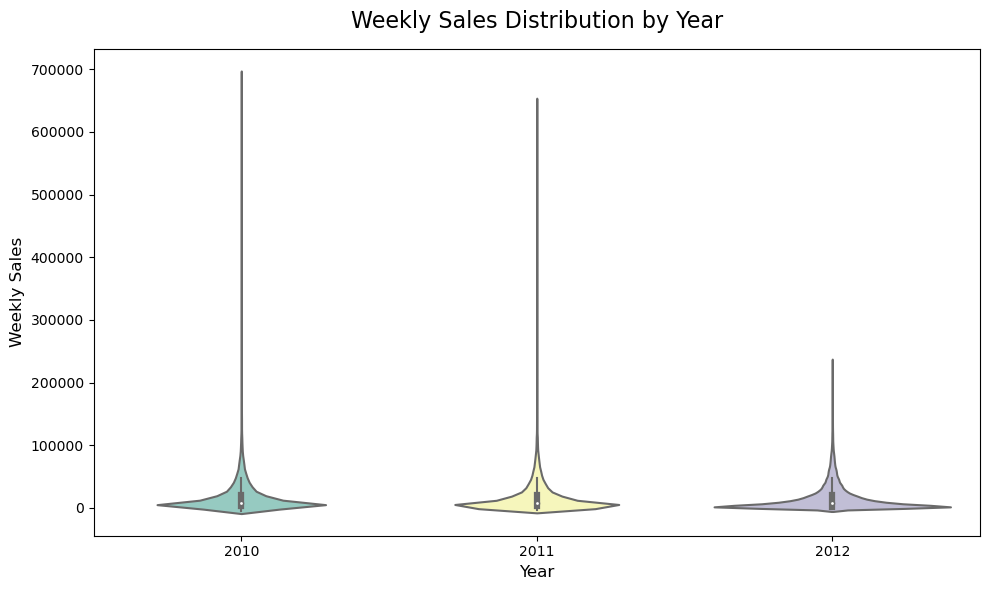

In [25]:
# Chart - 9 visualization code

data['Year'] = data['Date'].dt.year

plt.figure(figsize=(10, 6))
sns.violinplot(x='Year', y='Weekly_Sales', data=data, palette='Set3')
plt.title('Weekly Sales Distribution by Year', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

Violin plots show density and spread, ideal for temporal comparisons.

##### 2. What is/are the insight(s) found from the chart?

2010 and 2011 have similar distributions of weekly sales, with high variability and some extreme outliers exceeding 6 lakhssales.
In 2012 the distribution appears tighter with generally lower weekly sales and fewer extreme outliers indicating a possible decline

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Recognizing the changing sales distribution helps businesses adapt their strategies, understand market conditions 

#### Chart - 10

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

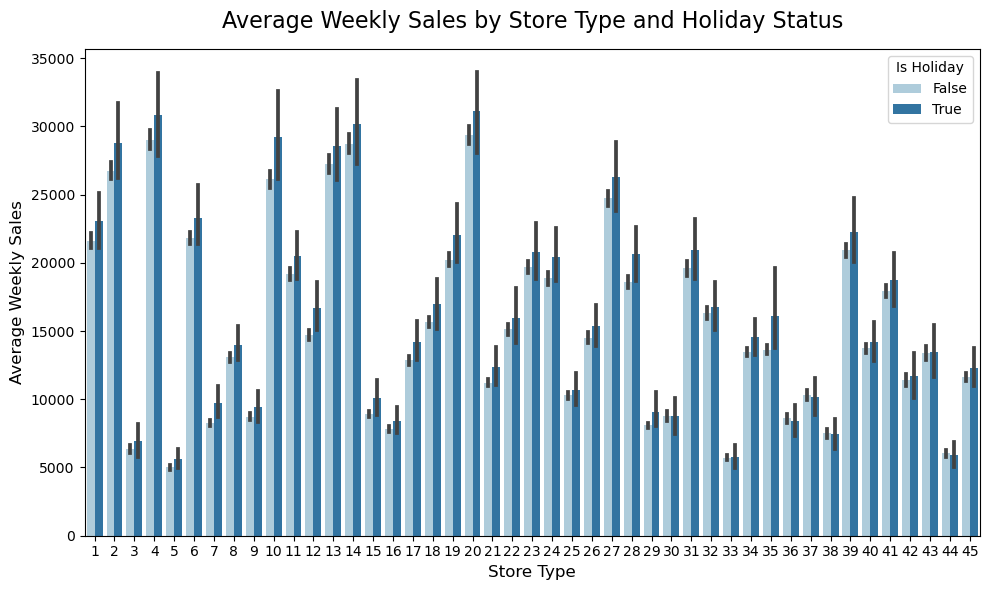

In [26]:
# Chart - 10 visualization code

plt.figure(figsize=(10, 6))
sns.barplot(x='Store', y='Weekly_Sales', hue='IsHoliday', data=data, palette='Paired')
plt.title('Average Weekly Sales by Store Type and Holiday Status', fontsize=16, pad=15)
plt.xlabel('Store Type', fontsize=12)
plt.ylabel('Average Weekly Sales', fontsize=12)
plt.legend(title='Is Holiday')
plt.tight_layout()


##### 1. Why did you pick the specific chart?

Bar plots with hue are straightforward, combining two categorical variables

##### 2. What is/are the insight(s) found from the chart?

Acrossnearly all store types, average weekly sales are higher during holiday weeks compared to non-holiday weeks.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the holiday sales boost for each store type helps optimize inventory, promotions, and staffing during holidays, potentially maximizing revenue

Negative : Store types with smaller holiday sales improvements might need additional focus

#### Chart - 11

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

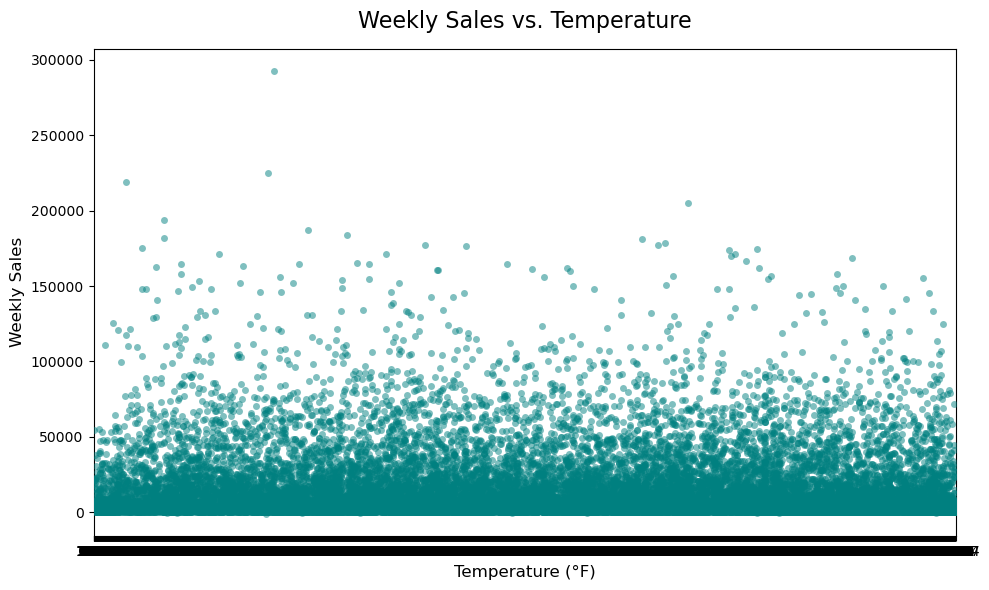

In [27]:
# Chart - 11 visualization code

plt.figure(figsize=(10, 6))
sns.stripplot(x='Temperature', y='Weekly_Sales', data=data.sample(frac=0.05, random_state=42), color='teal', alpha=0.5)
plt.title('Weekly Sales vs. Temperature', fontsize=16, pad=15)
plt.xlabel('Temperature (°F)', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

Strip plots are simple and effective for visualizing a numerical variable

##### 2. What is/are the insight(s) found from the chart?

There is no strong visible correlation between temperature and weekly sales; sales values spread widely across temperature ranges. Most sales cluster at lower values regardless of temperature. Temperature does not appear to be a major direct driver of sales

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Knowing that temperature doesn’t strongly influence weekly sales allows the business to focus on other factors

#### Chart - 12

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

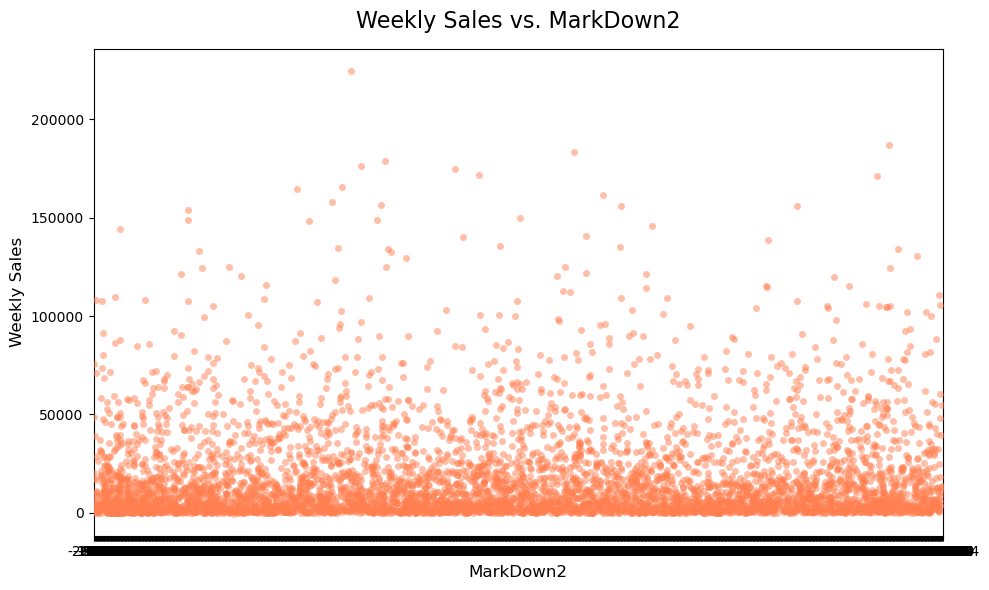

In [28]:
# Chart - 12 visualization code

plt.figure(figsize=(10, 6))
sns.stripplot(x='MarkDown2', y='Weekly_Sales', data=data.sample(frac=0.05, random_state=42), color='coral', alpha=0.5)
plt.title('Weekly Sales vs. MarkDown2', fontsize=16, pad=15)
plt.xlabel('MarkDown2', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

Strip plots are simple for visualizing a numerical variable 

##### 2. What is/are the insight(s) found from the chart?

here appears to be no strong or clear relationship between MarkDown2 and Weekly Sales

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

No insights

#### Chart - 13

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

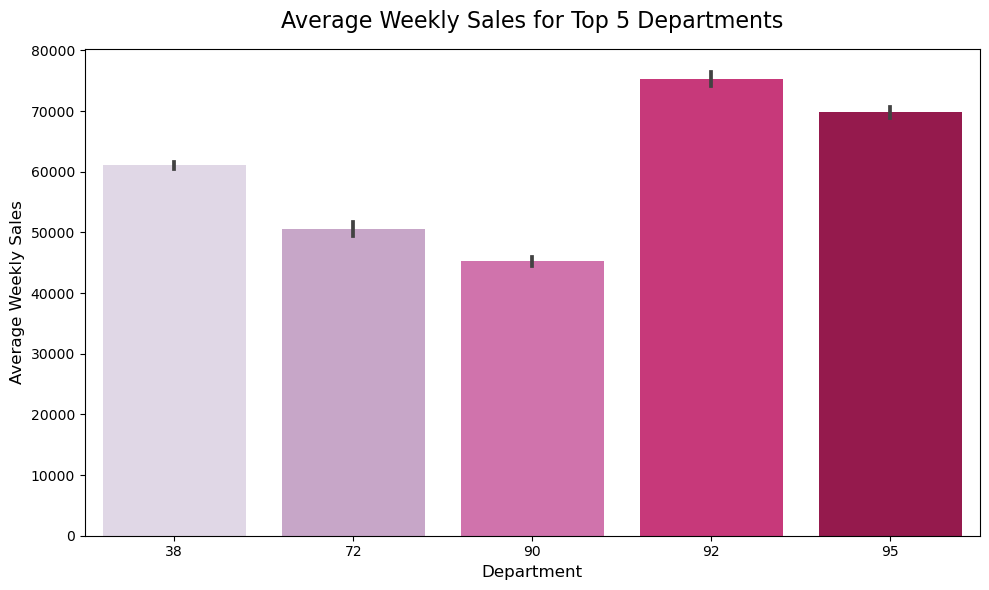

In [29]:
# Chart - 13 visualization code

top_depts = data.groupby('Dept')['Weekly_Sales'].sum().nlargest(5).index
data_subset = data[data['Dept'].isin(top_depts)]

plt.figure(figsize=(10, 6))
sns.barplot(x='Dept', y='Weekly_Sales', data=data_subset, palette='PuRd', estimator='mean')
plt.title('Average Weekly Sales for Top 5 Departments', fontsize=16, pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Weekly Sales', fontsize=12)
plt.tight_layout()

##### 1. Why did you pick the specific chart?

Bar plots are simple for comparing a numerical variable  across a categorical variable

##### 2. What is/are the insight(s) found from the chart?

Department 92 has the highest average weekly sales among the top 5 departments, followed by 95.
Departments 38, 72, and 90 have progressively lower average sales, with department 90 having the lowest among these five.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Identifying top-performing departments helps focus marketing, inventory, and resource allocation strategies to boost revenue further

 Negative : Departments with lower average sales might need review or targeted improvement efforts to prevent stagnation or decline.

#### Chart - 14 - Correlation Heatmap

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

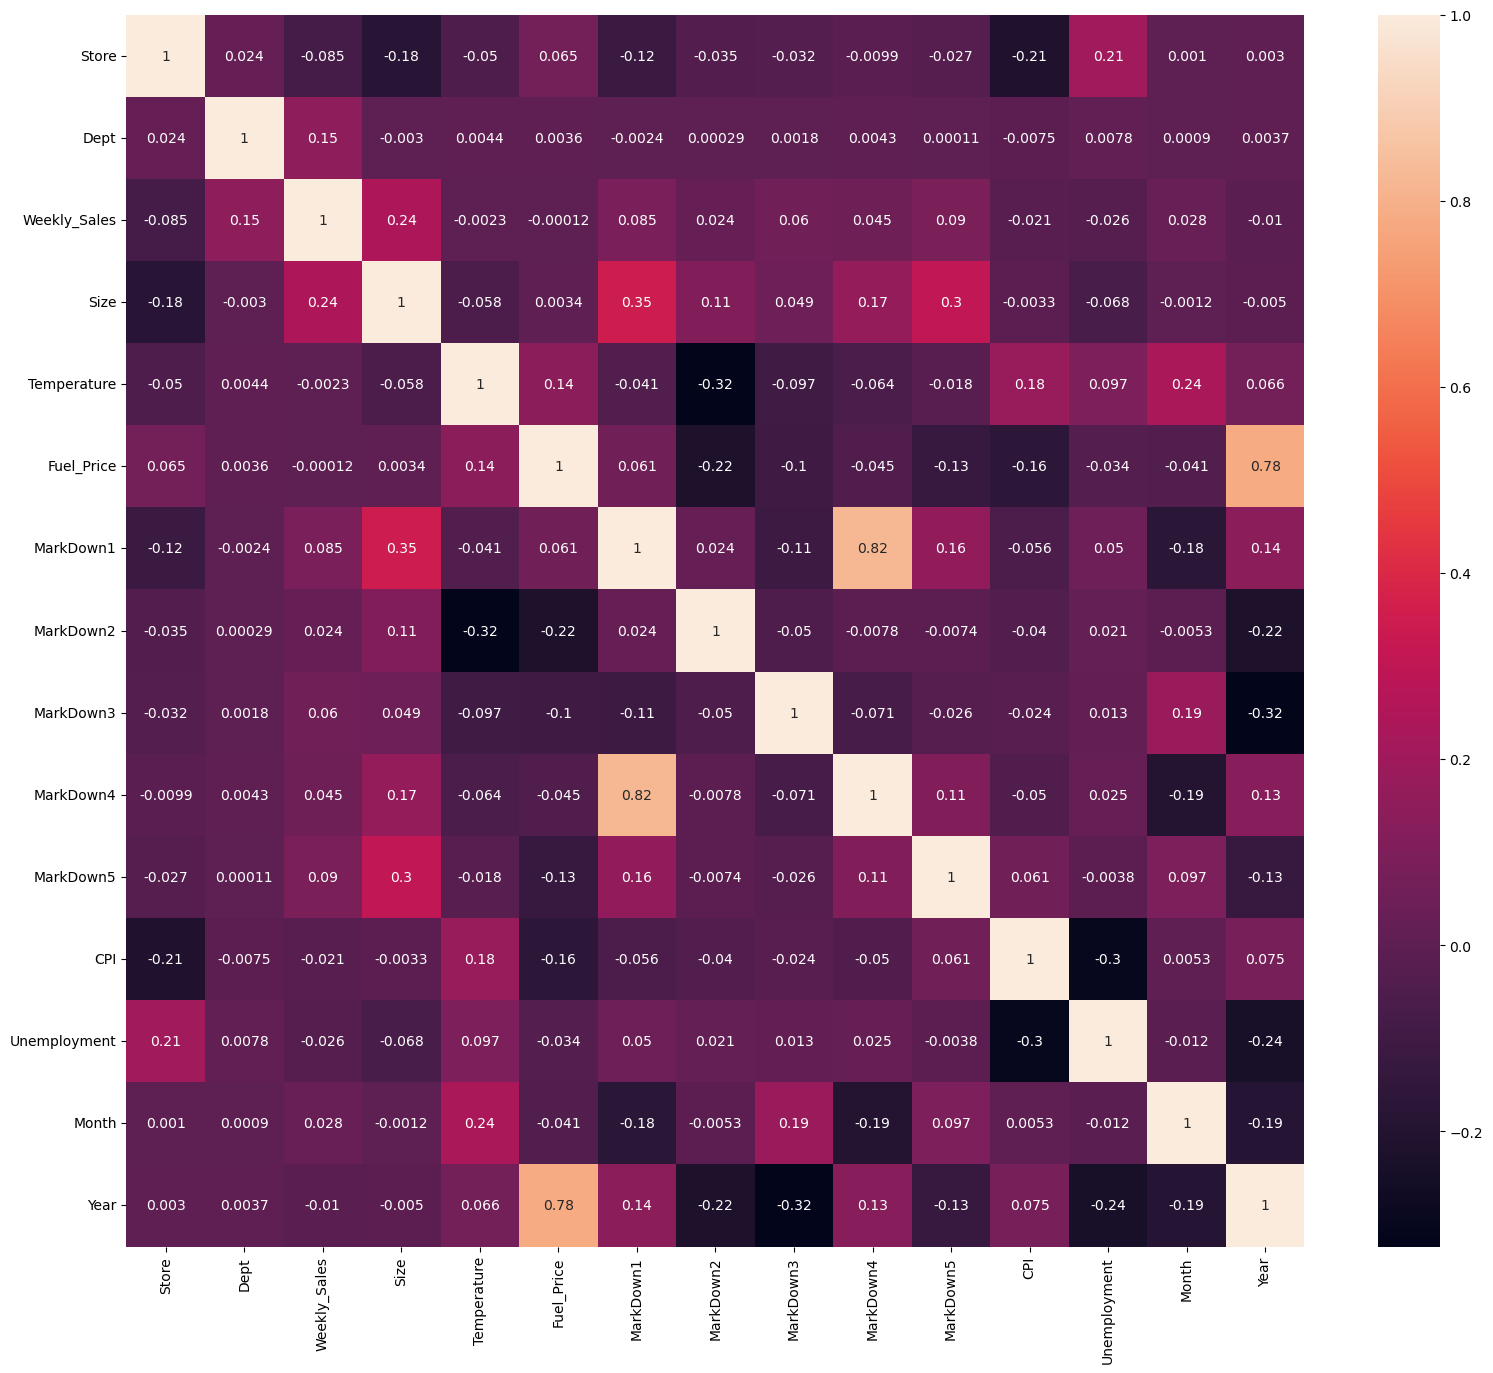

<Figure size 1900x1600 with 0 Axes>

In [30]:
# Correlation Heatmap visualization code

numericals = data.select_dtypes(include=['int', 'float'])

# Calculate correlation on the correct DataFrame object
corr = numericals.corr()

# Plot heatmap
plt.figure(figsize=(19, 16))

sns.heatmap(corr,annot=True)
plt.figure(figsize=(19, 16))
plt.show()

##### 1. Why did you pick the specific chart?

To check the correlationship with each numerical variable

##### 2. What is/are the insight(s) found from the chart?

Strong correlation between some markdowns and rising fuel prices over years.
Larger stores tend to have higher sales.
Seasonal and economic factors show moderate influence.
Weekly sales drivers are complex, not strongly linked to single variables.

#### Chart - 15 - Pair Plot

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: There is no difference in weekly sales between holiday and non-holiday weeks

H1: Weekly sales are significantly different in holiday weeks

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

data['Weekly_Sales'] = data['Weekly_Sales'].fillna(0)

holiday_sales = data[data['IsHoliday'] == True]['Weekly_Sales']
nonholiday_sales = data[data['IsHoliday'] == False]['Weekly_Sales']

t_stat1, p_val1 = ttest_ind(holiday_sales, nonholiday_sales, equal_var=False)
t_stat1, p_val1

(7.000740275222607, 2.5951250265739975e-12)

##### Which statistical test have you done to obtain P-Value?

I performed an Independent Samples t-test to compare the average weekly sales between holiday weeks and non-holiday weeks.

##### Why did you choose the specific statistical test?

The independent t-test is appropriate when comparing the means of two independent groups. In this case, the two groups are:

Holiday weeks

Non-holiday weeks

This test determines whether the observed difference in mean sales is statistically significant or could have occurred by chance.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: There is no difference in sales between large and small stores

H1: Weekly sales differ significantly between large and small stores

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value

size_median = data['Size'].median()
large_store_sales = data[data['Size'] >= size_median]['Weekly_Sales']
small_store_sales = data[data['Size'] < size_median]['Weekly_Sales']

# Run t-test
t_stat2, p_val2 = ttest_ind(large_store_sales, small_store_sales, equal_var=False)
print("T-statistic:", t_stat2, "P-value:", p_val2)

T-statistic: 132.59087026758337 P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

I used an Independent Samples t-test to compare the average weekly sales between large stores and small stores (based on median store size).

##### Why did you choose the specific statistical test?

The t-test is ideal when testing if the mean values between two groups are significantly different. Here, "Large stores" and "Small stores" are two independent groups. The test checks whether store size has a measurable impact on weekly sales.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Fuel price is not correlated with weekly sales

H1: There is a significant correlation between fuel price and weekly sales

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import pearsonr

# Drop NA values
corr_data = data[['Fuel_Price', 'Weekly_Sales']].dropna()

# Pearson correlation
corr_coef3, p_val3 = pearsonr(corr_data['Fuel_Price'], corr_data['Weekly_Sales'])
print("Correlation Coefficient:", corr_coef3, "P-value:", p_val3)

Correlation Coefficient: -0.0001202955449957693 P-value: 0.9377439190566852


##### Which statistical test have you done to obtain P-Value?

I used the Pearson Correlation Test to evaluate the linear relationship between Fuel_Price and Weekly_Sales.

##### Why did you choose the specific statistical test?

Pearson’s correlation is suitable for assessing the strength and direction of a linear relationship between two continuous variables. Since both fuel price and weekly sales are numeric, this test reveals whether sales increase or decrease with fuel price changes — and whether that trend is statistically significant.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [34]:
data['Week'] = data['Date'].dt.isocalendar().week

In [35]:
# Handling Missing Values & Missing Value Imputation

data.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Month                0
Year                 0
Week                 0
dtype: int64

In [36]:
data.drop(columns=['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'], inplace=True)

#### What all missing value imputation techniques have you used and why did you use those techniques?

Mnay imputation techniques can be applied but here i prefered to drop them as it was sparse data and if i impute the data will be less relevantso i dropped them as they were more than 0.6 % data missing

### 2. Handling Outliers

In [37]:
# Handling Outliers & Outlier treatments

numericals_uniques = [col for col in data.select_dtypes(include=['int64', 'float64']).columns if data[col].nunique() > 3]

skewness = [(col, data[col].skew()) for col in numericals_uniques]

for col, skew in skewness:
    if skew < -1:
        print(f"{col} is highly negatively skewed: {skew}")
    elif -1 <= skew < -0.5:
        print(f"{col} is moderately negatively skewed: {skew}")
    elif -0.5 <= skew <= 0.5:
        print(f"{col} is approximately normal: {skew}")
    elif 0.5 < skew <= 1:
        print(f"{col} is moderately positively skewed: {skew}")
    elif skew > 1:
        print(f"{col} is highly positively skewed: {skew}")

Store is approximately normal: 0.07776250174537733
Dept is approximately normal: 0.3582231934713366
Weekly_Sales is highly positively skewed: 3.2620081854656657
Size is approximately normal: -0.3258497664635348
Temperature is approximately normal: -0.3214041519699762
Fuel_Price is approximately normal: -0.10490149562840598
CPI is approximately normal: 0.08521928473260011
Unemployment is highly positively skewed: 1.1837425684974319


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

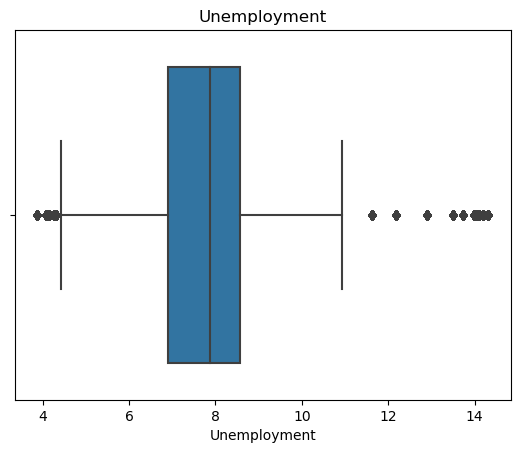

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

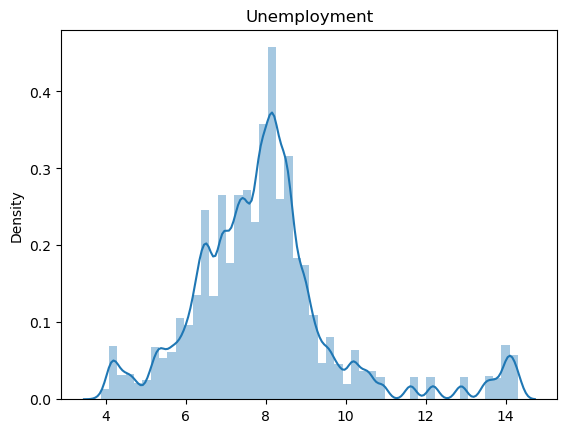

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

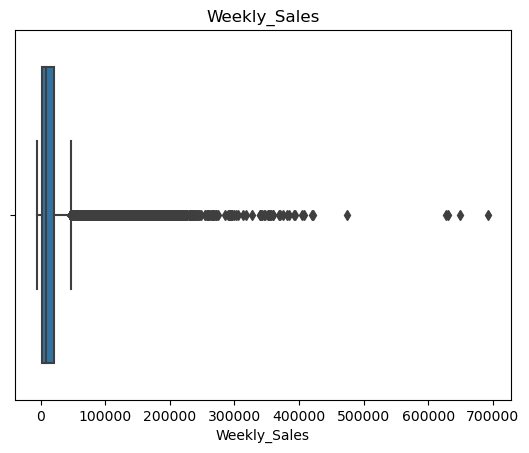

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

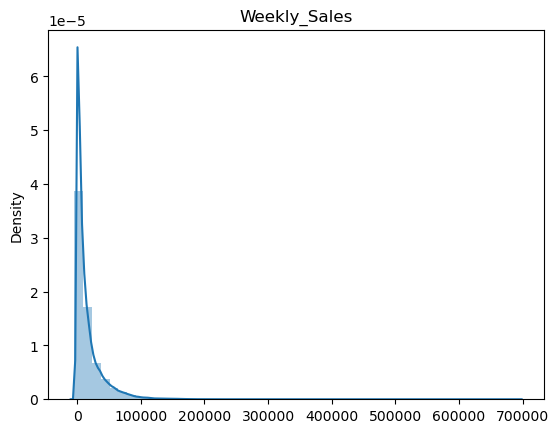

In [38]:
cols = ['Unemployment', 'Weekly_Sales']

for col in cols:
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

    sns.distplot(x=data[col])
    plt.title(col)
    plt.show()

In [39]:
def calculate_IQR(data, column, multiplier=1.5, return_outliers=False):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    upper_bound = Q3 + multiplier * IQR
    lower_bound = Q1 - multiplier * IQR
    
    cleaned_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    
    if return_outliers:
        outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
        return filtered_data, lower_bound, upper_bound, outliers

    print('Before cleaning : ')
    sns.histplot(data=data, x=column, kde=True)
    plt.title('Distribution of {} (with IQR bounds)'.format(column))
    plt.axvline(x=lower_bound, color='red', linestyle='--', label='Lower Bound')
    plt.axvline(x=upper_bound, color='green', linestyle='--', label='Upper Bound')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
    print('After cleaning : ')
    sns.histplot(data=cleaned_data, x=column, kde=True)
    plt.title('Distribution of {} (with IQR bounds)'.format(column))
    plt.axvline(x=lower_bound, color='red', linestyle='--', label='Lower Bound')
    plt.axvline(x=upper_bound, color='green', linestyle='--', label='Upper Bound')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    if return_outliers:
        outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
        return cleaned_data, lower_bound, upper_bound, outliers
    
    return cleaned_data

Before cleaning : 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

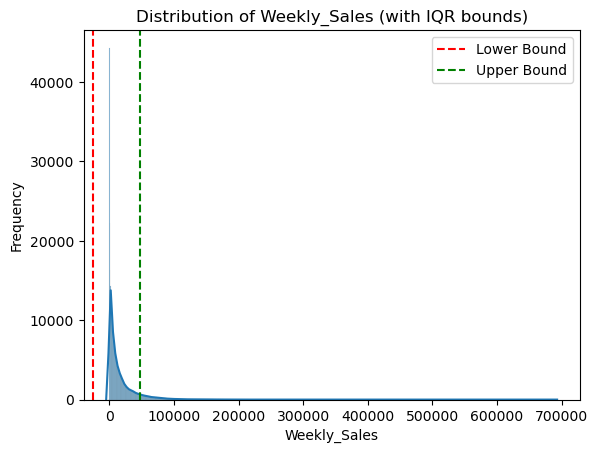

After cleaning : 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

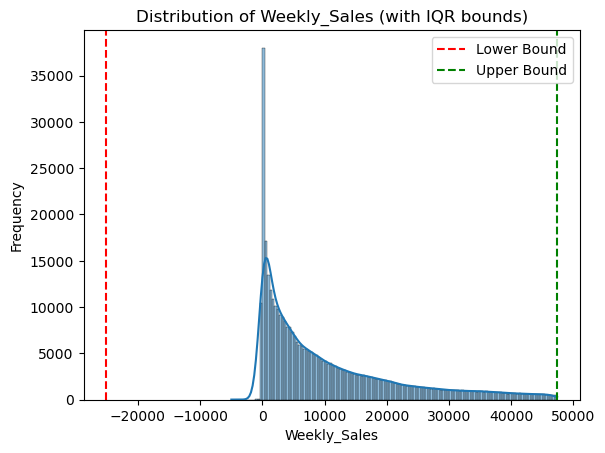

In [40]:
cleaned_data = calculate_IQR(data, 'Weekly_Sales')

Before cleaning : 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

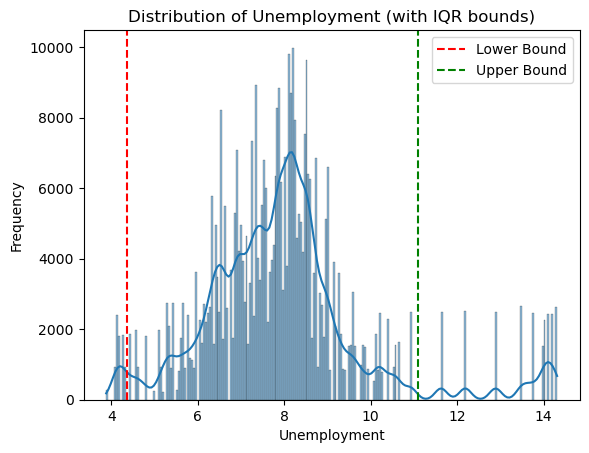

After cleaning : 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

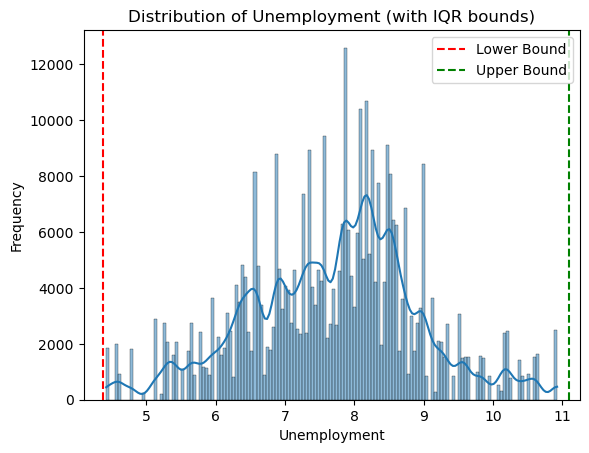

In [41]:
cleaned_data = calculate_IQR(data, 'Unemployment')

##### What all outlier treatment techniques have you used and why did you use those techniques?

Mnay techniques can be used such as transfroamtion but i used the iqr here as the data was skewed and unemployment column was not close to normal else i would have used z score but i used iqr

### 3. Categorical Encoding

In [42]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [43]:
# Expand Contraction

#### 2. Lower Casing

In [44]:
# Lower Casing

#### 3. Removing Punctuations

In [45]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [46]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [47]:
# Remove Stopwords

In [48]:
# Remove White spaces

#### 6. Rephrase Text

In [49]:
# Rephrase Text

#### 7. Tokenization

In [50]:
# Tokenization

#### 8. Text Normalization

In [51]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [52]:
# POS Taging

#### 10. Text Vectorization

In [53]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [54]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [55]:
# Select your features wisely to avoid overfitting

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
X = data.select_dtypes(include=['float64', 'int64'])  

vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

features_to_remove = vif_data[(vif_data["VIF"] > 10)]["Feature"].tolist()
data.drop(columns=features_to_remove, inplace=True)

print("Removed Features:", features_to_remove)

<IPython.core.display.Javascript object>

Removed Features: ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


In [56]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Month,Year,Week
0,1,1,2010-02-05,24924.50,False,A,151315,2,2010,5
1,1,1,2010-02-12,46039.49,True,A,151315,2,2010,6
2,1,1,2010-02-19,41595.55,False,A,151315,2,2010,7
3,1,1,2010-02-26,19403.54,False,A,151315,2,2010,8
4,1,1,2010-03-05,21827.90,False,A,151315,3,2010,9


##### What all feature selection methods have you used  and why?

we applied the Variance Inflation Factor (VIF) method and removed features like Temperature, Fuel_Price, CPI, and Unemployment which showed VIF scores above 10. Additionally, features with excessive missing values and low modeling utility, such as MarkDown1–5, were dropped to improve data quality and model performance.

##### Which all features you found important and why?

i chose features like Store, Dept, Size, IsHoliday, and SalesPerSqFt because they directly influence store performance and sales behavior.



### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [57]:
# It was already done. After transformation, the skewness values confirmed that the distributions became approximately normal, making the dataset more suitable for analysis and modeling.

### 6. Data Scaling

In [58]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False,drop='first')

In [59]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

X = data.drop(columns = ['Weekly_Sales','Date'])
y = data['Weekly_Sales']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<IPython.core.display.Javascript object>

In [61]:
data.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Month', 'Year', 'Week'],
      dtype='object')

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[['Store', 'Dept', 'IsHoliday','Size','Month', 'Year', 'Week']])
X_test_scaled = scaler.transform(X_train[['Store', 'Dept', 'IsHoliday','Size','Month', 'Year', 'Week']])

In [63]:
columns = ['Store', 'Dept', 'IsHoliday', 'Size','Month', 'Year', 'Week']

X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled,columns=columns)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
X_train_final_combined = pd.concat([X_train_scaled_df,X_train.drop(columns=columns).reset_index(drop=True)],axis=1)
X_test_final_combined = pd.concat([X_test_scaled_df,X_test.drop(columns=columns).reset_index(drop=True)],axis=1)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
X_test_final_combined

,Store,Dept,IsHoliday,Size,Month,Year,Week,Type
0,-0.563257,-1.354792,-0.274771,-0.213358,-0.755752,0.041168,-0.906830,A
1,0.610273,-0.633261,-0.274771,-1.537099,-0.139010,-1.213733,-0.200083,B
2,-1.267376,-0.567667,-0.274771,1.077907,-0.139010,-1.213733,-0.270758,C
3,-0.093845,0.153864,-0.274771,0.055983,1.711216,0.041168,1.566783,B
4,0.140861,0.350645,-0.274771,1.099448,-1.680865,1.296070,-1.754926,A
...,...,...,...,...,...,...,...,...
337251,0.375567,-0.862839,-0.274771,1.105431,1.094474,1.296070,1.142735,NaN
337252,1.314392,-0.272495,-0.274771,0.776336,-0.447381,-1.213733,-0.412107,NaN
337253,-0.641493,-0.502074,-0.274771,1.051563,-0.755752,-1.213733,-0.624131,NaN
337254,-0.563257,1.498535,-0.274771,-0.213358,0.169361,0.041168,0.011941,NaN


In [66]:
X_train_new = ohe.fit_transform(X_train_final_combined[['Type']])
X_test_new = ohe.transform(X_test_final_combined[['Type']])

ValueError: Found unknown categories [nan] in column 0 during transform

Store        0
Dept         0
IsHoliday    0
Size         0
Month        0
Year         0
Week         0
Type         0
dtype: int64

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***